# Mixed Sparse Coding

:::{admonition} Reference
:class: tip

ref
one word on the bad frontiers venue.
:::


Let us now have a look at the DLRA problem when the sparsity level is larger than one. As we have seen in the [one-sparse DLRA problem](onesparseDLRA.ipynb), the DLRA problem is tricky to solve. With the goal of designing alternating optimization algorithms for DLRA, it is necessary to first study the subproblem of estimating a column-wise k-sparse matrix $X$. The resulting estimation problem, coined Mixed Sparse Coding (MSC), is the following:

$$ \min_{X\in\Omega_{X},\; \|X[:,q]\|_0\leq k\; \forall q\leq r } \|Y - DXB^T \|_F^2 $$

where matrix $B$ is assumed full column rank. Recall that $\Omega_X$ typically stands for $\mathbb{R}^{d\times r}$ or $\mathbb{R}^{d\times r}_+$.

This problem is studied in particular in {cite}`cohenDictionaryBasedLowRankApproximations2022`, below we provide a short and incomplete overview of the results obtained in this work. It also relates to the [sparse NNLS problem](sparse_nnls.ipynb) discussed later.

## A few observations

The MSC problem is obviously related to the sparse coding problem, which is recovered when $r=n=1$. In particular, MSC shares a few properties with sparse coding:
- If the support of matrix $X$ is fixed/known in advance, it is possible to compute the nonzero values of $X$ exactly. Indeed, MSC can be reformulated in a vectorized way $ \text{vec}(Y) \approx (D\otimes B) \text{vec}(X) $, and therefore a linear system can be built by selecting the columns of $D\otimes B$ which correspond to nonzero elements in $\text{vec}(X)$. Whether or not this linear system is overdetermined depends on the sparsity level $k$, the sizes $m$ and $d$, and also the spark of the dictionary $D$.
- Solutions to MSC are generically unique if the dictionary $D$ has spark strictly greater than $2k$. The proof is, in fact, the same as in sparse coding because $B$ is full column rank.
But there are also some important differences between MSC and sparse coding. For instance, when the dictionary is orthogonal, unless the rank is exactly one, MSC is not solved by hard-thresholding. Similarly, the case $k=1$, which is covered in the previous section, is not trivial, while in sparse coding it is solved by computing the maximum correlation between atoms and the data matrix $Y$.

Since MSC and sparse coding are not the same problems, it is relevant to propose dedicated algorithms for solving MSC, inspired by sparse coding. Two families of algorithms are typically proposed for sparse coding: greedy algorithms and convex relaxations. We propose algorithms from both families in the following.

## Heuristics for MSC

### A retrospective look on MC-ALS

A naive heuristic to solve MSC consists of assuming that there is no noise. In that case, denoting as $C$ the right pseudo-inverse of $B$, we known that 

$$ YC = DX $$

which allows us to compute the optimal matrix $X$ by solving sparse coding, for instance with Orthogonal Matching Pursuit {cite} [todo]. In particular, when $k=1$ the optimum is obtained by a single iteration of Matching Pursuit. This heuristic, coined Trick-OMP (Trick Orthogonal Matching Pursuit), is in fact exactly the approach used in MC-ALS [described earlier](onesparseDLRA.ipynb) (not the linear assignment variant). While this is correct in the noiseless case, it is a priori unclear how robust this method can be. The following theorem is one possible characterization of the robustness of Trick-OMP. I show that when the noise level is small compared to the conditioning of both matrices $B$ and $D$, the Trick-OMP procedure can identify the support of the solution.

```{margin}
Matrix $X'$ stands for the estimate produced by the MC-ALS algorithm, while $X$ is the ground truth solution to the mixed sparse coding problem.
```

```{prf:theorem}
:label: robustness_trickMP
Let $ X,X'$ two columnwise $ k $-sparse matrices and $ \epsilon>0,\; \delta>0 $ such that $ \|Y-DXB\|_F^2 \leq \epsilon $ and $ \|YB(B^TB)^{-1} - DX' \|_F^2 \leq \delta $. Further suppose that $ \text{spark}(D)>2k $ and that $ B $ has full column-rank. Then
    
$$ \|X-X'\|_F \leq \frac{1}{\sigma^{(2k)}_{\min}(D)}\sqrt{\delta+\frac{\epsilon}{\sigma^2_{\min}(B)}}$$
where $ \sigma_{\min}(B) $ is the smallest nonzero singular value of matrix $ B $ and $ \sigma_{\min}^{(2k)} $ is the smallest nonzero singular value of all submatrices of $ D $ constructed with $ 2k $ columns.

Under these hypotheses, supposing that $ X $ and $ X' $ are exactly columnwise $ k $-sparse, if

$$    \min_{j\leq r}\sqrt{\min_{i\in \text{Supp}(X_j)} {X_{ij}}^2 + \min_{ i'\in \text{Supp}(X_j')} {X'_{i'j}}^2} >  \frac{1}{\sigma^{(2k)}_{\min}(D)}\sqrt{\delta+\frac{\epsilon}{\sigma^2_{\min}(B)}},$$
then matrices $X$ and $X'$ have the same support, $\text{Supp}(X) = \text{Supp}(X')$.

See {cite}`cohenDictionaryBasedLowRankApproximations2022` for the proof.
```

While this result shows that Trick-OMP is theoretically robust, in practice, Trick-OMP starts showing poor performance at medium noise levels. Since we aim at solving MSC inside an alternating algorithm, we cannot expect that $Y=DXB^T$ holds even approximately at each iteration. Using Trick-OMP as an MSC solver for DLRA is generally ill-advised unless an excellent initialization can be provided.

### Another greedy approach: Hierarchical OMP

Another algorithm we proposed is Hierarchical Orthogonal Matching Pursuit (HOMP). It is a direct adaptation of OMP for MSC. It is indeed possible to show that MSC
can be solved column per column as a sparse coding problem, e.g., using OMP. 
Both Trick-OMP and HOMP are implemented in the library [dlra]() available online. The implementation of these algorithms is too complex to allow their detailed implementation here.

### A tightest convex relaxation approach

Popular approaches to solve sparse coding problems are to relax the $\ell_0$ function 
```{margin}
The $\ell_0$ function is not a norm, and not even a pseudo-norm in the strict mathematical sense because it is not homogeneous. I prefer to call it the $\ell_0$ function to avoid ambiguity.
```
using its convex enveloppe, the $\ell_1$ norm. The optimization problem then becomes convex and easier to solve, but the challenge is to assess whether the solutions to the relaxed problem are the solutions of the original sparse coding problem {cite}[todo] Foucart. 

In the Mixed Sparse Coding problem, it is possible to show that we are in fact solving a problem of the form

$$ \min_{X} \| X \|_{0,0} \text{ such that } \|Y - DXB^T\|_F^2\leq \epsilon $$

for some positive $\epsilon$. We defined the loss function as

$$ \ell_{0,0}(X) = \sum_{\|z\|_0=1} \|Xz\|_0 = \max_{i} \|X[:,i]\|_0. $$

In other words, MSC can be seen as a min-max problem where the solution must have the smallest number $k$ of nonzero elements per column to fit the data, but each column may use as many nonzero elements up to $k$.

```{note}
The $\ell_{p,q}$ matrix norm here is defined as $\ell_{p,q}(X) = \sup_{\|z\|_p=1} \|Xz\|_q $, which is the convention used in the linear algebra community, but not in the machine learning community. 
```

A first strategy to solve MSC is to mimic the sparse coding case and compute the tightest convex relaxation of the $\ell_{0,0}$ function. This can be done, and I showed that this relaxation is exactly the $\ell_{1,1}$ matrix norm defined as

$$ \ell_{1,1}(X) = \max_i \|X[:,i]\|_1 .$$

```{margin}
The proof is purely analytic and rather straightforward; it relies on computing twice the convex enveloppe of the $\ell_{0,0}$ function.
```

In an unpublished note {cite}[todo], I showed how to compute the proximity operator of the $\ell_{1,1}$ matrix norm to propose an adaptation of ISTA to the MSC problem. Dokmanic and co-authors have also proposed an algorithm to compute this proximity operator, which is slightly faster and simpler and therefore should be used instead {cite}[todo]. But an immediate issue with this regularization term is that it only penalizes columns of $X$ that have $\ell_1$ norm saturated to the largest value across all columns. In other words, one cannot regularized columns of $X$ which have vastly different $\ell_1$ norms, while this may be the case in the ground truth solution. This can be formalized with the following result, which shows that some (possibly all but one!) columns of the regularized solution may not be sparse.
```{prf:theorem}
Suppose the $\ell_{1,1}$ relaxed problem has a unique solution $X^\ast$. Let $I$ the set of indices such that for any $i$ in $I$, $\|X^\ast[:,i]\|_1 = \|X^\ast\|_{1,1}$. Denote $S$ the support of $X^\ast$. Then there exists at least one index $i$ in $I$ such that $D[:,S[i]]$ is full column rank and $\|X^\ast[:,i]\|_0\leq n$.
```

Experiments conducted in {cite}`cohenDictionaryBasedLowRankApproximations2022` moreover showed that this approach performs worse than a simpler approach we now desribe.

### A simpler convex relaxation

A simpler strategy consists of penalizing each column of matrix $X$ with the $\ell_1$ norm. We then solve a problem of the form

$$ \min_{X\in\Omega_X} \|Y - DXB^T\|^2_F + \sum_{i=1}^{r}\lambda_i \|X[:,i]\|_1 $$

This second approach, coined Block-Lasso, is simple because we can easily compute gradients and apply column by column the soft-thresholding operator (which is the proximity operator of the $\ell_1$ norm). However, it requires introducing one regularization parameter $\lambda_i>0$ for each column of the matrix $X$. This is tedious, in particular since designing homotopy algorithms that can automatically select these values is not straightforward at all. 

To tune all the $\lambda_i$ parameters, we assume that the desired sparsity level $k$ for each column is known. Parameters $\lambda_i$ can then be tuned dynamically with a simple heuristic in order to reach $k$ nonzero entries, inside an iterative algorithm. The resulting algorithm is coined Block-FISTA and is a Proximal Fast Gradient algorithm with heuristically adaptive regularization weights.

We may compare the three proposed methods (Trick-OMP, HOMP, Block-FISTA) as MSC solvers, as is done in {cite}`cohenDictionaryBasedLowRankApproximations2022`. However, to remain concise, we show below an example of usage of an alternating algorithm using Block-FISTA as an MSC solver, applied to smooth canonical polyadic decomposition.

## DLRA for Smooth Canonical Polyadic Decomposition

```{margin}

For low-dimensional linear models of the parameter matrices in most rLRA models, the trick of computing the QR decomposition of the basis of the low-dimensional linear space is often a useful trick for numerical efficiency, that works beyond smoothness and B-splines.

```

One possible application of DLRA is to impose smoothness constraints in tensor decompositions with splines. The idea of using splines in the CP decomposition is due to Timmerman and Kiers [TODO ref]. They proposed to constrain one of the factors of the CP decomposition of an input tensor $T\in\R{n_1\times n_2\times n_3}_+$, say matrix $A$, to be decomposed exactly in a basis $U\in\R{n_1\times p}_+$ of B-splines, such that $A = UZ$. The columns of matrix $U$ are the individual splines that compose this basis. The user has to choose the splines manually, by placing knots in the 1D plane and choosing the polynomial degrees. There are typically only a few B-splines, such that $p\leq n_1$, and the smoothness constraint allows for dimensionality reduction. Numerically, Timmerman computes the QR decomposition of $U=QR$ and projects the data tensor, such that $Q^TA\times_1 T$ is the new compressed data. 

The problem of choosing the B-spline by hand is mild for an experienced user with precise knowledge of the expected outcome of the CP decomposition, but can plague the practical usage of this method by novice users. Using DCPD, it is possible to automatically select the relevant splines in a large dictionary of polynomials, by building an explicit dictionary $D$ stacking all the candidates splines. The sparse regression then picks the best splines numerically; another advantage of this method is that different components (columns of matrix $A$) may use different splines. This comes at the cost of having to solve a large DLRA problem. This probably makes the method realistically impractical for usage in chemometrics, but the goal of this experiment is rather to showcase one possible application of DLRA. Below we perform DLRA for rank three CP decomposition with smoothness on the second mode, using $251$ splines for a tensor of size $18\times 251\times 21$ with sparsity level $k=6$.

As a baseline comparison, we also perform nonnegative CP decomposition without sparsity of smoothness constraints, and then compute either NNLS or  sparse NNLS. The results below show that DLRA is better than these two-step procedures in terms of MSE. We also use data smoothing with QR decomposition, but since there are as many splines as dimensions on the second mode, the smoothing has essentially no effect.


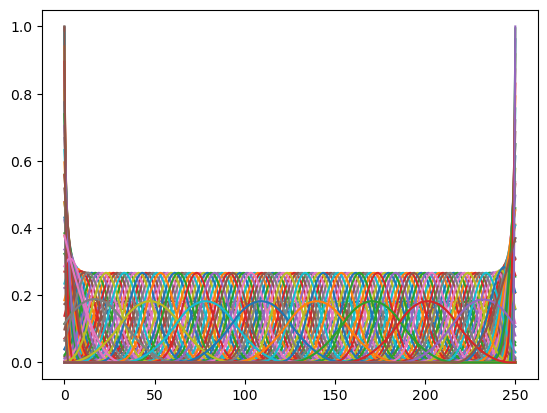

In [2]:
import numpy as np
import tensorly as tl
import tlviz.visualisation
import matplotlib.pyplot as plt
import urllib.request
from tensorly_hdr.image_utils import generate_splines_DLRA

rank = 3 
subsample = False # False or int <?

D = generate_splines_DLRA(251, [30,10,30], [4,8,4]) # generates some splines, this is a handcrafted function, not intended for general use
if subsample:
    D = D[:,:subsample] # taking only first 60 atoms, to make the dictionary tall/undercomplete
    # Then the choice of the splines matters a lot.

plt.plot(D)
plt.show()

# Loading the data from online repo https://gitlab.com/tensors/tensor_data_eem
# and move it to the dataset folder of tensorly_hdr
# urllib.request.urlretrieve('https://gitlab.com/tensors/tensor_data_eem/-/raw/master/EEM18.mat?ref_type=heads', '../tensorly_hdr/dataset/eem.mat') 
# The dataset is also distributed with the code directly

# Time for a little dance with MATLAB and Python dataset formats
import scipy.io
import xarray
import tlviz
data = scipy.io.loadmat('../../tensorly_hdr/dataset/eem.mat')
tensor = data['X']['data']
tensor = tl.tensor(tensor[0,0])
tensor = tensor/tl.max(tensor)
# adding noise
tensor_noised = tensor + 0.2*np.random.randn(*tensor.shape)
# Creating a dataset for tlviz
dataset = xarray.DataArray(
    data = tensor_noised,
    coords={
        "Sample index": np.linspace(1,18,18),
        "Emission wavelength": np.linspace(250, 500, 251),
        "Excitation wavelength": np.linspace(210, 310, 21)
    },
    dims = ["Sample index", "Emission wavelength", "Excitation wavelength"]
)
# Plotting raw data
from tensorly.decomposition import non_negative_parafac_hals
raw_cp = non_negative_parafac_hals(tensor, rank, n_iter_max=100, init='svd') # noiseless 'GT' 
mse_raw = tl.norm(tensor - raw_cp.to_tensor())**2/tl.prod(tl.shape(dataset.data))
 
# Computing nonnegative CP on noisy data
out = non_negative_parafac_hals(dataset.data, rank, n_iter_max=100, init='svd')
out.normalize()
mse = tl.norm(tensor - out.to_tensor())**2/tl.prod(tl.shape(dataset.data))

# Computing (not nonnegative!) CP with preconditioning using the splines (Timmerman et. al.)
Q, R = np.linalg.qr(D)
precond_data = tl.tenalg.mode_dot(dataset.data, Q@Q.T, mode=1)
out_precond = non_negative_parafac_hals(precond_data, rank, n_iter_max=100, init='svd')
mse_precond = tl.norm(tensor - out_precond.to_tensor())**2/tl.prod(tl.shape(dataset.data))
# too many splines, need to pick some by hand...
# also same splines for all components!

# Running Sparse Coding as a post processing, with fista
from tensorly.solvers.nnls import fista, hals_nnls
from copy import deepcopy
out_ls = deepcopy(out)
Xls = hals_nnls(D.T@out_ls[1][1], D.T@D, V=Q.T@out_ls[1][1]) # nonnegative least squares
out_ls[1][1] = D@Xls
mse_ls = tl.norm(tensor - out_ls.to_tensor())**2/tl.prod(tl.shape(dataset.data))

out_sc = deepcopy(out)
lamb = 0.1
Xsc = fista(D.T@out_sc[1][1], D.T@D, sparsity_coef=lamb, tol=0, n_iter_max=1000) # fista
out_sc[1][1] = D@Xsc
mse_sc = tl.norm(tensor - out_sc.to_tensor())**2/tl.prod(tl.shape(dataset.data))

# Testing the proposed DLRA algorithm
from dlra.algorithms import dlra_parafac
k = 6
perm_data = tl.transpose(dataset.data, [1,0,2])
init_dlra = tl.cp_tensor.CPTensor((None, [np.copy(out_precond[1][i]) for i in [1,0,2]])) # initialized with Timmerman approach
X0 = np.copy(Xsc)
out_dlra, _, _ = dlra_parafac(perm_data, rank, [D], [k], nonnegative=True, lamb_rel = [1e-3], tau=5, X0=[X0], tol=0, n_iter_max = 20, init = init_dlra)
out_dlra = tl.cp_tensor.CPTensor((None, [out_dlra[1][i] for i in [1,0,2]]))
mse_dlra = tl.norm(tensor - out_dlra.to_tensor())**2/tl.prod(tl.shape(dataset.data))


In [39]:
# Computing all residuals
print(f"MSE for:\n raw data {mse_raw},\n noisy data {mse},\n smoothed data {mse_precond},\n nnls on D {mse_ls},\n ALS + sparse coding {mse_sc},\n DLRA {mse_dlra}")


MSE for:
 raw data 1.1123106110343988e-05,
 noisy data 0.00026866076475430843,
 smoothed data 0.00013210545183094905,
 nnls on D 0.00011035045506677822,
 ALS + sparse coding 0.0002835241634360601,
 DLRA 7.13474360248694e-05


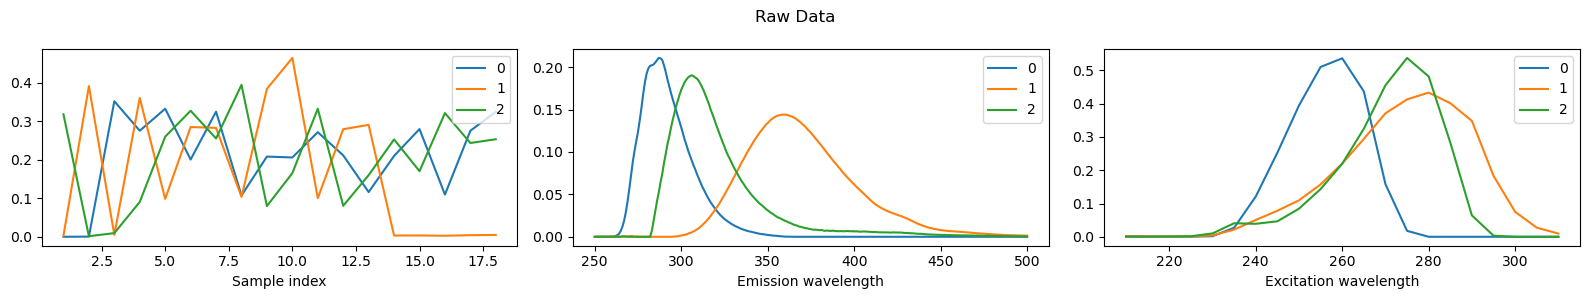

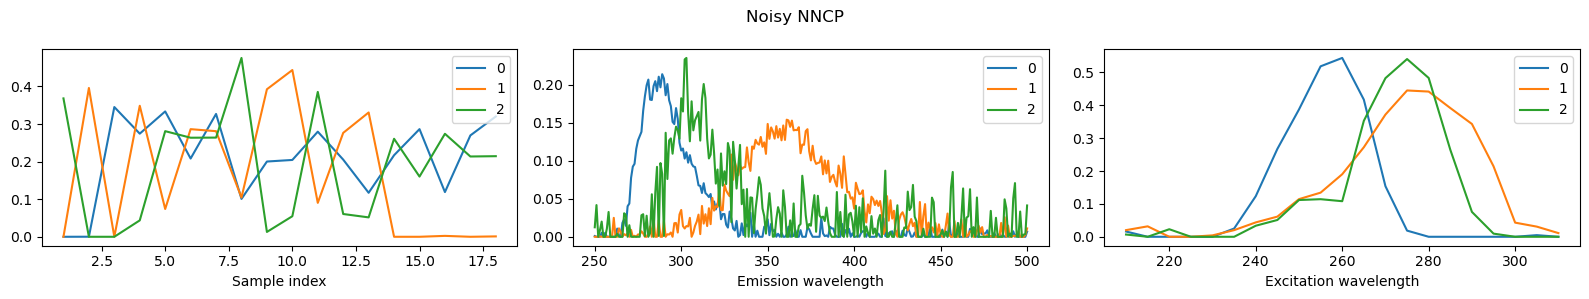

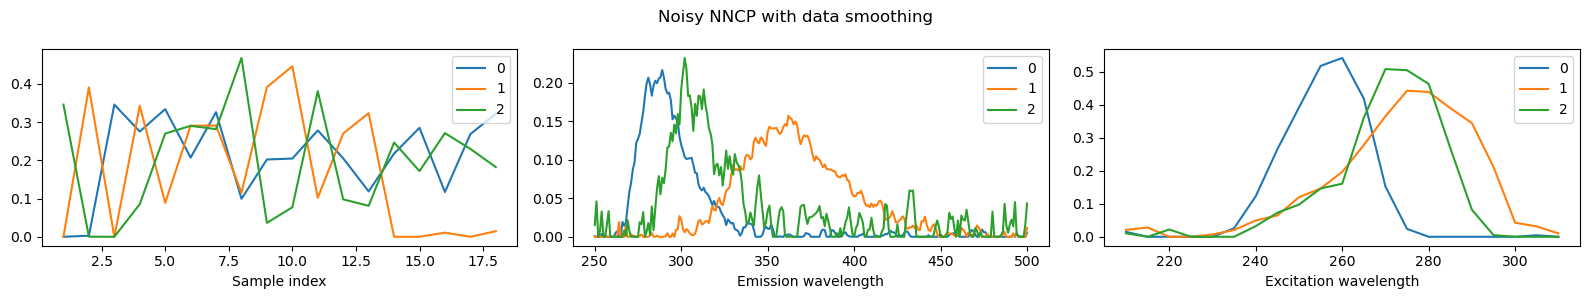

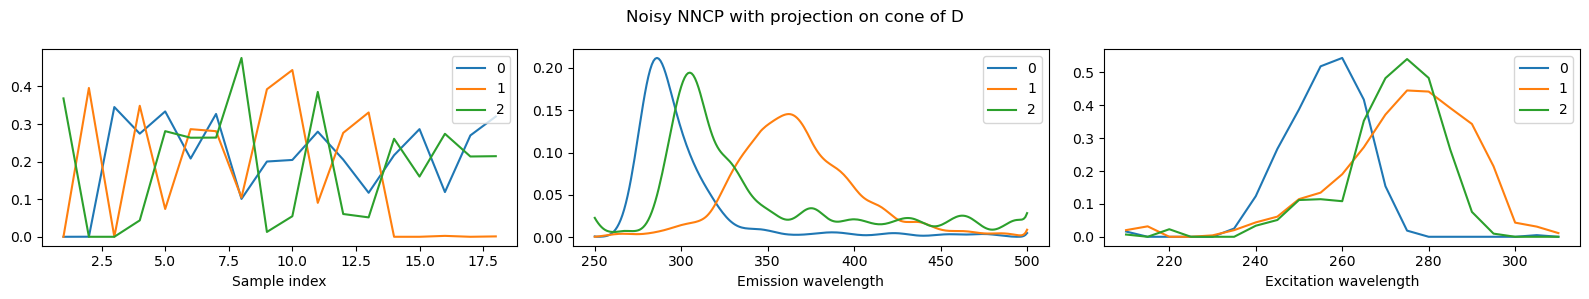

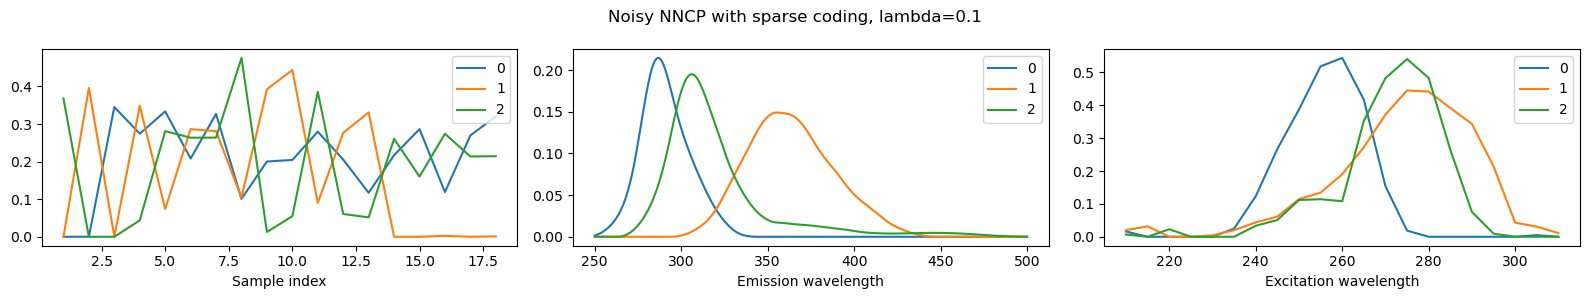

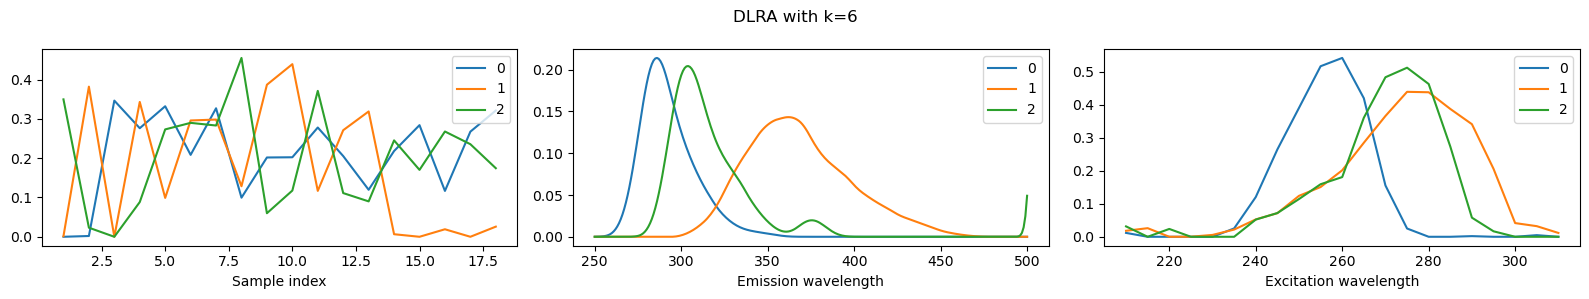

In [ ]:
# Visualization
def plot_results(out_cp, title):
    cp_to_plot = tlviz.postprocessing.postprocess(out_cp, dataset)
    fig, _ = tlviz.visualisation.components_plot(cp_to_plot)
    fig.suptitle(title)
    plt.show()
    
plot_results(raw_cp, "Raw Data") 
plot_results(out, "Noisy NNCP") 
plot_results(out_precond, "Noisy NNCP with data smoothing (Timmerman et al.)") 
plot_results(out_ls, "Noisy NNCP with projection on cone of D") 
plot_results(out_sc, f"Noisy NNCP with sparse coding, lambda={lamb}") 
plot_results(out_dlra, f"DLRA with k={k}") 